# Testing VideoMAE processor

In [1]:
import torch

print(torch.__version__, torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.9.1+cu126 True
NVIDIA GeForce RTX 4070 Laptop GPU


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from transformers import VideoMAEImageProcessor

from aitraf.video_mae.utils import load_target_label_mappings
from aitraf.video_mae.processing import process_clip

#### Load manifest row

In [3]:
CLIPS_DIR = Path("../data/clips")
MANIFEST_PATH = Path("../data/manifests/train.jsonl")
MANIFESTS_DIR = MANIFEST_PATH.parent
SAMPLE_FRAMES = 16
ROW_INDEX = 0

manifest_df = pd.read_json(MANIFEST_PATH, lines=True)
sample_row = manifest_df.iloc[ROW_INDEX].to_dict()
sample_row

{'video_id': '25-11-17 21-46-00 5743-00.02.32.654-00.02.38.141-seg03.mp4',
 's3_path': 's3://aitraf/clips/25-11-17 21-46-00 5743-00.02.32.654-00.02.38.141-seg03.mp4',
 'trick': 'fs-royale',
 'key_foot': 'right',
 'person': 'Henrikas'}

#### Process clip with VideoMAE processor

In [4]:
_, label2id, id2label = load_target_label_mappings(MANIFESTS_DIR)

processor = VideoMAEImageProcessor.from_pretrained("MCG-NJU/videomae-base")


def process_with_sampling(sampling_dist: str):
    processed = process_clip(
        sample_row,
        processor,
        CLIPS_DIR,
        label2id,
        SAMPLE_FRAMES,
        sampling_dist=sampling_dist,
    )
    return processed["pixel_values"], processed["labels"]


pixel_values_uniform, labels_uniform = process_with_sampling("uniform")
pixel_values_normal, labels_normal = process_with_sampling("normal")

((pixel_values_uniform.shape, labels_uniform), (pixel_values_normal.shape, labels_normal))


(torch.Size([16, 3, 224, 224]), tensor(2))

#### Visualize normalized frames for each sampling distribution

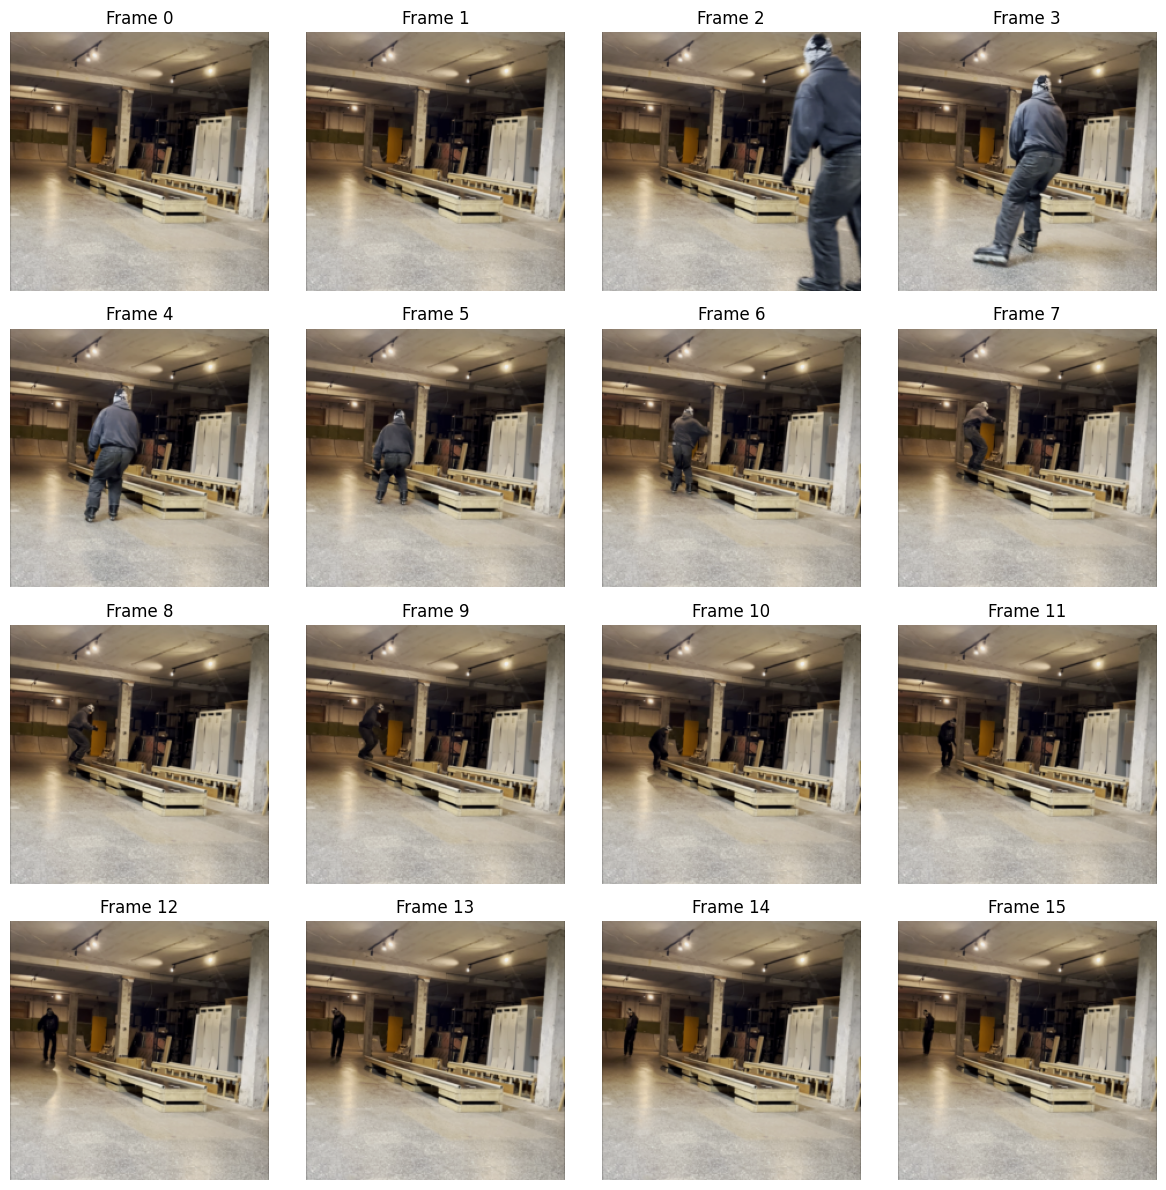

In [5]:
def tensor_to_image(frame_tensor):
    frame = frame_tensor.detach().cpu()
    mean = torch.tensor(processor.image_mean).view(3, 1, 1)
    std = torch.tensor(processor.image_std).view(3, 1, 1)
    frame = frame * std + mean
    frame = (frame * 255).clamp(0, 255).byte()
    return frame.permute(1, 2, 0).numpy()


def plot_frames(pixel_values):
    frames = [tensor_to_image(frame) for frame in pixel_values]
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    for idx, ax in enumerate(axes.flat):
        if idx >= len(frames):
            ax.axis("off")
            continue
        ax.imshow(frames[idx])
        ax.set_title(f"Frame {idx}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


#### Uniform sampling

In [ ]:
plot_frames(pixel_values_uniform)

#### Normal sampling

In [ ]:
plot_frames(pixel_values_normal)